# Price/Volatility Acceleration and Jerk

- 1st order (velocity): `Returns`

- 2nd order (acceleration): `dReturns/dt`

- 3rd order (jerk): `dAcceleration/dt`

- Volatility velocity: `dSigma/dt` where sigma is rolling return volatility

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter


# Savgol Smoothening

- Savitzky-Golay Filter (scipy.signal.savgol_filter)

- Polynomial window-based smoothing

- Preserves sharp features and peaks

In [11]:
def smooth_savgol(series: pd.Series, window_length: int = 11, polyorder: int = 3) -> pd.Series:

    valid_mask = series.notna()
    if valid_mask.sum() < window_length:
        return series
    
    smoothed = series.copy()
    valid_data = series[valid_mask].values
    
    if len(valid_data) >= window_length:
        smoothed_data = savgol_filter(valid_data, window_length=window_length, polyorder=polyorder)
        smoothed[valid_mask] = smoothed_data
    
    return smoothed

vol_window = 20
sg_window = 11  
sg_polyorder = 3  

# Path stuff
OUTPUT_DIR = Path.cwd() / 'smoothed_data_savgol'
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path.cwd().parent / 'smoothed_data_savgol'

OUTPUT_DIR.mkdir(exist_ok=True)

DATA_DIR = Path.cwd() / 'ohlcv_data_with_features'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / 'ohlcv_data_with_features'

csv_files = sorted(DATA_DIR.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No CSV files found in ohlcv_data_with_features')

print(f'Processing {len(csv_files)} stocks...\n')

# batch loop
for i, ticker_path in enumerate(csv_files, 1):
    df = pd.read_csv(ticker_path)

    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)
    
    # dynamics
    df['Acceleration'] = df['Returns'].diff()
    df['Jerk'] = df['Acceleration'].diff()
    
    df['Sigma'] = df['Returns'].rolling(vol_window).std()
    df['Volatility_Velocity'] = df['Sigma'].diff()
    
    # smooth
    df['Acceleration_SG'] = smooth_savgol(df['Acceleration'], window_length=sg_window, polyorder=sg_polyorder)
    df['Jerk_SG'] = smooth_savgol(df['Jerk'], window_length=sg_window, polyorder=sg_polyorder)
    df['Volatility_Velocity_SG'] = smooth_savgol(df['Volatility_Velocity'], window_length=sg_window, polyorder=sg_polyorder)
    
    # Save karo
    output_path = OUTPUT_DIR / ticker_path.name
    df.to_csv(output_path, index=False)
    
    if i % 50 == 0 or i == len(csv_files):
        print(f'Processed {i}/{len(csv_files)} stocks')

print(f'\n All data saved to: {OUTPUT_DIR}')

Processing 400 stocks...

Processed 50/400 stocks
Processed 100/400 stocks
Processed 150/400 stocks
Processed 200/400 stocks
Processed 250/400 stocks
Processed 300/400 stocks
Processed 350/400 stocks
Processed 400/400 stocks

 All data saved to: /Users/mihirdeogaonkar/dev/repos/financial-data-analysis/smoothed_data_savgol


# Plotting of AARTIIND.NS

For visualisation of the smoothed data along with the raw data. 
Hardcoded, purely for illustrative purposes

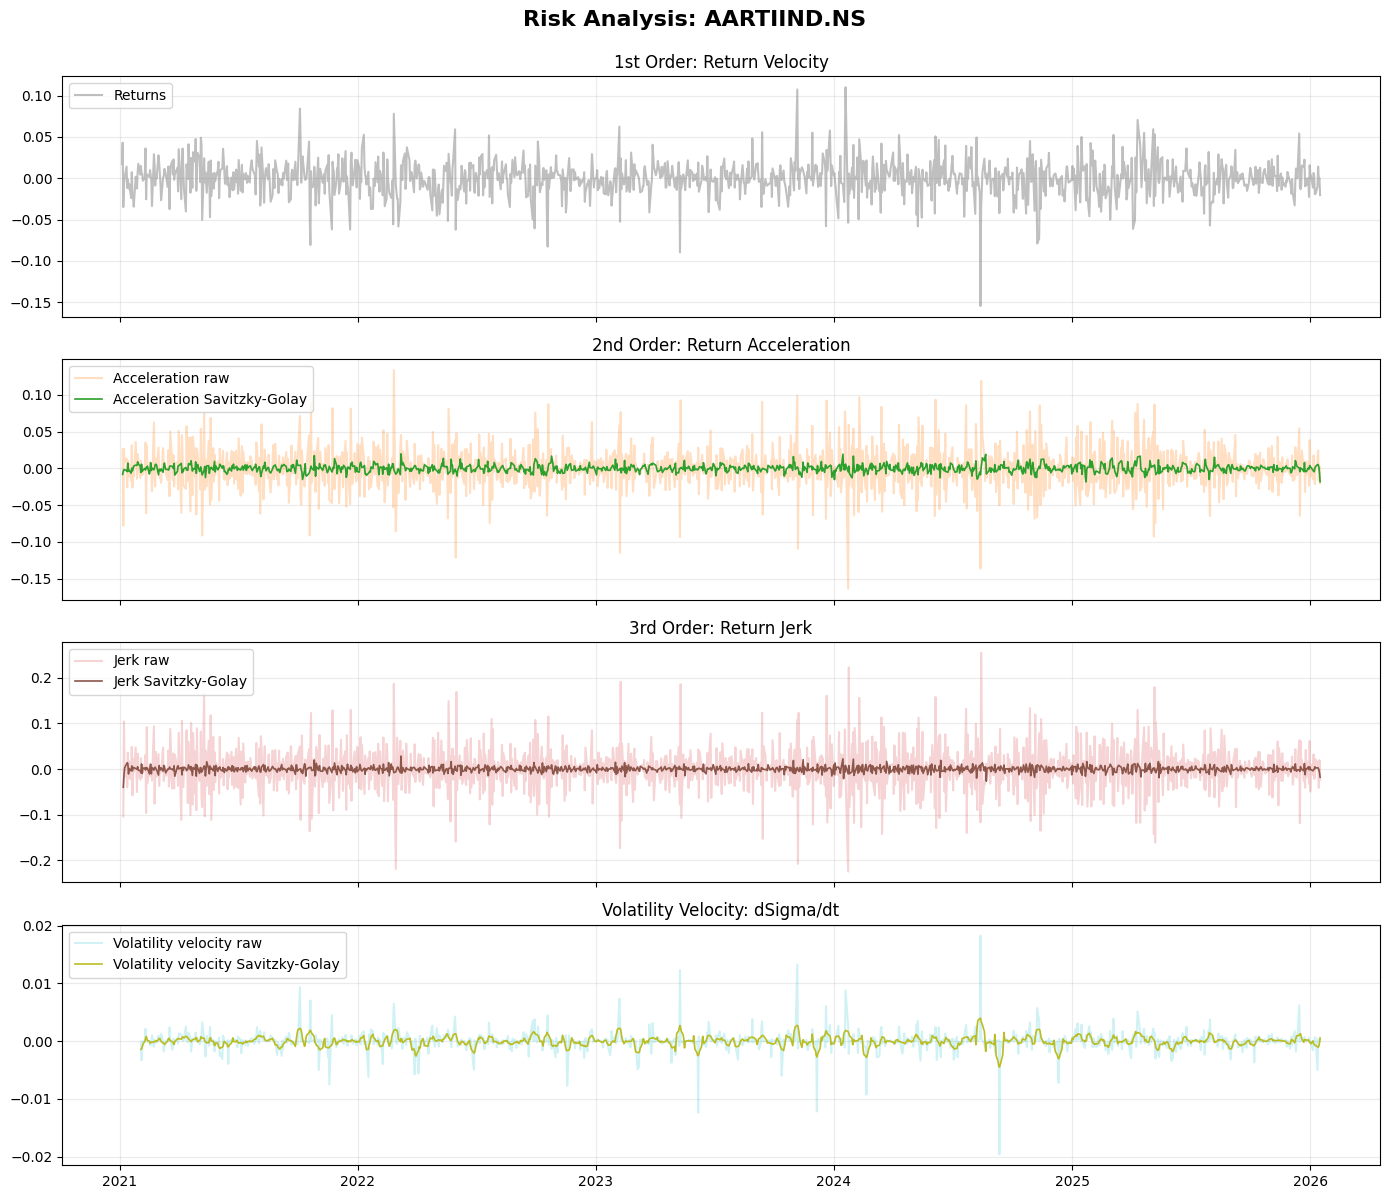

In [12]:
smoothed_files = sorted(OUTPUT_DIR.glob('*.csv'))
stock_to_plot = smoothed_files[0]  # yeh badal to see different stock ka data
ticker_name = stock_to_plot.stem 

plot_df = pd.read_csv(stock_to_plot)

if 'Date' in plot_df.columns:
    x = pd.to_datetime(plot_df['Date'], errors='coerce')
else:
    x = plot_df.index

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Risk Analysis: {ticker_name}', fontsize=16, fontweight='bold', y=0.995)

axes[0].plot(x, plot_df['Returns'], color='gray', alpha=0.5, label='Returns')
axes[0].set_title('1st Order: Return Velocity')
axes[0].legend(loc='upper left')

axes[1].plot(x, plot_df['Acceleration'], color='tab:orange', alpha=0.25, label='Acceleration raw')
axes[1].plot(x, plot_df['Acceleration_SG'], color='tab:green', linewidth=1.2, label='Acceleration Savitzky-Golay')
axes[1].set_title('2nd Order: Return Acceleration')
axes[1].legend(loc='upper left')

axes[2].plot(x, plot_df['Jerk'], color='tab:red', alpha=0.2, label='Jerk raw')
axes[2].plot(x, plot_df['Jerk_SG'], color='tab:brown', linewidth=1.2, label='Jerk Savitzky-Golay')
axes[2].set_title('3rd Order: Return Jerk')
axes[2].legend(loc='upper left')

axes[3].plot(x, plot_df['Volatility_Velocity'], color='tab:cyan', alpha=0.2, label='Volatility velocity raw')
axes[3].plot(x, plot_df['Volatility_Velocity_SG'], color='tab:olive', linewidth=1.2, label='Volatility velocity Savitzky-Golay')
axes[3].set_title('Volatility Velocity: dSigma/dt')
axes[3].legend(loc='upper left')

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Event-Based Forward Return Study (Smoothed Kinematic Signals)

- Signals: `Velocity` (returns), `Acceleration_SG`, `Jerk_SG`

- Event definition: observations below 10th percentile and above 90th percentile

- Outcome: forward cumulative returns across multiple horizons to inspect momentum/mean-reversion

In [ ]:
signal_columns = {
    'Velocity': 'Returns',
    'Acceleration': 'Acceleration_SG',
    'Jerk': 'Jerk_SG',
}

data_dir = Path.cwd() / 'smoothed_data_savgol'
if not data_dir.exists():
    data_dir = Path.cwd().parent / 'smoothed_data_savgol'

files = sorted(data_dir.glob('*.csv'))
if not files:
    raise FileNotFoundError('No files found in smoothed_data_savgol')

sample_file = files[0] #yeh badal to test different stock ka data
sample_df = pd.read_csv(sample_file)

print(f'Sample ticker: {sample_file.stem}')
print(f'Rows: {len(sample_df)}\n')

rows = []
for signal_name, col in signal_columns.items():
    if col not in sample_df.columns:
        continue

    s = sample_df[col].dropna()
    p10 = s.quantile(0.10)
    p50 = s.quantile(0.50)
    p90 = s.quantile(0.90)

    low_count = int((sample_df[col] <= p10).sum())
    high_count = int((sample_df[col] >= p90).sum())

    rows.append({
        'Signal': signal_name,
        'Column': col,
        'p10': float(p10),
        'p50': float(p50),
        'p90': float(p90),
        'LowTail_count': low_count,
        'HighTail_count': high_count,
    })

percentile_table = pd.DataFrame(rows)
display(percentile_table)

Sample ticker: AARTIIND.NS
Rows: 1250



,Signal,Column,p10,p50,p90,LowTail_count,HighTail_count
0,Velocity,Returns,-0.023133,-0.000068,0.022119,125,125
1,Acceleration,Acceleration_SG,-0.006306,-0.000125,0.006218,125,125
2,Jerk,Jerk_SG,-0.007891,0.000088,0.007627,125,125
